<a href="https://colab.research.google.com/github/mf1060/ml-2026/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Michael Furey

Dr. Forouraghi

Machine Learning

September 25, 2026

The following notebook describes the analysis and findings for Assignment 3. The purpose of this assignment is to analyze a dataset on customer churn from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). This dataset is read locally from Google colab.

Our goals are to use an SGD Classifier to predict when we may lose a customer given a certain set of variables.

This notebook uses code and methods from the class [End-to-End Machine Learning Project](https://github.com/bforoura/ML26/blob/main/Module2_ML_Projects/02_end_to_end_machine_learning_project.ipynb), the Module 2 and Module 3 Overview for this class, the Module 2 and Module 3 videos, and Chapters 2 and 3 of our textbook (Aurélien Géron, Hands-On Machine Learning with SciKit-Learn and PyTorch (2025)).

# Task 1: Loading the dataset



This notebook uses a dataset of customer churn from [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn). This dataset is read locally into Google colab. This code uses methods from the [Spam, No Spam Classification Notebook](https://github.com/bforoura/ML26/blob/main/Module3_Classification/spam_nospam_sgdclassifier.ipynb) including its documentation.

In [1]:
import pandas as pd

# Load the dataset from the Colab session
df = pd.read_csv('telco_churn.csv')

# Display the dimensions of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

Dataset Shape: 7043 rows, 21 columns



# Task 2: Inspection Methods

We will first use some inspection methods to get a sense of what this data looks like.

We first use `.head()` `.info()` to view the first 5 rows of this dataframe and their datatypes. We see a number of binary variables such as `Partner` and `Dependents` are encoded as objects ('Yes' and 'No'). There appears to be four numeric variables `SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`. However, `TotalCharges` is encoded as an object and this needs to converted to numeric.

In [2]:
# Display the first 5 rows
display(df.head())

# Print concise summary of columns, non-null counts, and data types
print("\nDataset Information:")
display(df.info())
display(df.describe())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

None

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Task 3: Dropping Non-Informative Identifiers

Here we will drop non-informative identifiers and specifically `CustomerID`.

In [3]:
# Dropping customerID
df.drop("customerID", axis=1, inplace=True)

# Task 4: Assessing Missing Values

The following uses methods from the [Spam, No Spam Classification Notebook](https://github.com/bforoura/ML26/blob/main/Module3_Classification/spam_nospam_sgdclassifier.ipynb) including its documentation to inspect the dataframe for missing values and imputing values. We know that `TotalCharges` will need to be converted to numeric.

Because object variables may have white space, we may need to remove this white space and replace with `np.nan` to view any variables that require imputation. The following tutorials were helpful for reference:

- [Stack Overflow](https://stackoverflow.com/questions/59476179/is-it-possible-to-change-pandas-column-data-type-within-a-sklearn-pipeline) post describing how to change a datatype in a pipeline.

- [GeeksForGeeks](https://www.geeksforgeeks.org/pandas/pandas-strip-whitespace-from-entire-dataframe/) discussing how to strip white space from columns.

- [Pandas Documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html) describing methods for replacing values in a dataframe. This is used to replace empty white space values with `np.nan`.

- [Geeks For Geeks](https://www.geeksforgeeks.org/python/how-to-convert-data-types-in-python-3/) describing how to convert data types.

- [Stack Overflow Article](https://stackoverflow.com/questions/43677933/converting-object-to-int-pandas) describing how to convert objects to int data types.

In [4]:
#import the numpy library
import numpy as np

# Taking a copy of the dataframe to inspect it
df_copy = df.copy()

#Removing white space from total charges and converting to numeric
df_copy['TotalCharges'] = df_copy['TotalCharges'].str.strip().replace('', np.nan).astype(float)
#Removing white space from categorical data
df_copy['gender'] = df_copy['gender'].str.strip().replace('', np.nan)
df_copy['Partner'] = df_copy['Partner'].str.strip().replace('', np.nan)
df_copy['Dependents'] = df_copy['Dependents'].str.strip().replace('', np.nan)
df_copy['PhoneService'] = df_copy['PhoneService'].str.strip().replace('', np.nan)
df_copy['MultipleLines'] = df_copy['MultipleLines'].str.strip().replace('', np.nan)
df_copy['InternetService'] = df_copy['InternetService'].str.strip().replace('', np.nan)
df_copy['OnlineSecurity'] = df_copy['OnlineSecurity'].str.strip().replace('', np.nan)
df_copy['OnlineBackup'] = df_copy['OnlineBackup'].str.strip().replace('', np.nan)
df_copy['DeviceProtection'] =  df_copy['DeviceProtection'].str.strip().replace('', np.nan)
df_copy['TechSupport'] = df_copy['TechSupport'].str.strip().replace('', np.nan)
df_copy['StreamingTV'] = df_copy['StreamingTV'].str.strip().replace('', np.nan)
df_copy['StreamingMovies'] = df_copy['StreamingMovies'].str.strip().replace('', np.nan)
df_copy['Contract'] = df_copy['Contract'].str.strip().replace('', np.nan)
df_copy['PaperlessBilling'] = df_copy['PaperlessBilling'].str.strip().replace('', np.nan)
df_copy['PaymentMethod'] = df_copy['PaymentMethod'].str.strip().replace('', np.nan)
df_copy['Churn'] = df_copy['Churn'].str.strip().replace('', np.nan)



Then we inspect the dataframe to determine any other missing values than `TotalCharges`. The good news is that we may only need to impute values for `TotalCharges`. After stripping white space from categorical columns, there are no missing values for other categorical values.

Our imputation strategy for `TotalCharges` may need to be filling in median values.

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Now, we inspect the dataframe copy for distribution of numeric columns. `SeniorCitizen` is a binary value. `Tenure` and `MonthlyCharges` may need to be standard-scaled in order to form a normal distribution ideal for machine learning models. `TotalCharges` has a long tail which may require log scaling in order to form a standard distribution.

We will apply standard scaling and on-hot encoding in Task 5 by creating a pipeline that separates categorical and numeric variables.

array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>,
        <Axes: title={'center': 'TotalCharges'}>]], dtype=object)

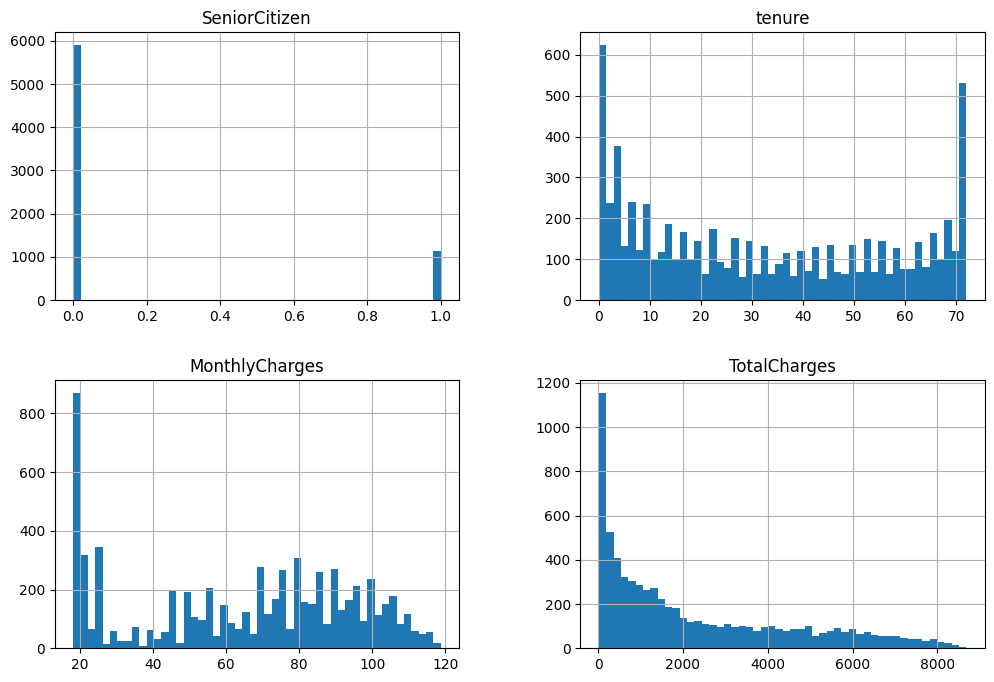

In [6]:
df_copy.hist(bins=50, figsize=(12, 8))

# Task 5: Implementing a Pipeline
The following uses methods from the [Spam, No Spam Classification Notebook](https://github.com/bforoura/ML26/blob/main/Module3_Classification/spam_nospam_sgdclassifier.ipynb) including its documentation to create a pipeline for numeric and categorical variables.

First, we will isolate feature columns to separate features from the target variable, `Churn`. Then, we will convert the `Churn` column to a numeric binary variable.

We will also conver total charges to their log values here before constructing the pipeline.

In [7]:
import numpy as np

# Selecting features to keep
feature_cols = [
       'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'
]

#Stripping whitespace from the total charges column and converting to a float value.
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan).astype(float)

X = df[feature_cols].copy()
y = [1 if i=='Yes' else 0 for i in df['Churn']]

#Log scaling TotalCharges because it becomes a little complicated doint so in the pipeline
df['TotalCharges'] = [np.log(i) for i in df['TotalCharges']]

#Task 6: Implementing Classifier and Pipeline

The following creates a pipeline for analysis. We are going to create two separate pipelines for the SGD Classifier that uses a min-max scaler or a standard scaler for numeric columns.

In [8]:
#Importing the method for a pipeline
from sklearn.pipeline import Pipeline
#Importing a simple imputer for filling empty values
from sklearn.impute import SimpleImputer
#Importing a one hot encoder for creating dummy variables for categorical data
from sklearn.preprocessing import OneHotEncoder
#Importing libraries for creating pipelines and a transformer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
#Importing a Standard Scaler to standardize values.
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_selector, make_column_transformer

#Importing SGD Classifier
from sklearn.linear_model import SGDClassifier


# Using methods from "end-to-end machine learning project"
# Using log scaling methods from pg. 160 of the full textbook linked to our class.
# Also Referencing a logtransformer method from: https://docs.kanaries.net/topics/Scikit-Learn/sklearn-pipeline
from sklearn.preprocessing import FunctionTransformer

# Identify numerical and categorical feature columns
numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges'
]
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

# The following defines a pipeline for log-scaling values. We first impute the
#median for missing values, we apply a log function to each value, and then a
#standard scaler.
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one")
)

# The following defines the pipeline for numeric values with
# a median and a standard scaler.
numeric_transformer_standard = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# The following defines the pipeline for numeric values with
# a median and a minmax scaler.
numeric_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('minmax', MinMaxScaler())
])

# Categorical transformation pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Defining a ColumnTransformer for standard scaling
preprocessor_standard = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_standard, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Defining a ColumnTransformer for MinMax scaling
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_minmax, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Assemble full pipeline with preprocessing and classifier for standard scaling
pipeline_standard = Pipeline(steps=[
    ('preprocessor', preprocessor_standard),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

# Assemble full pipeline with preprocessing and classifier for standard scaling
pipeline_minmax = Pipeline(steps=[
    ('preprocessor', preprocessor_minmax),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

print("Pipelines constructed successfully.")

Pipelines constructed successfully.


# Tasks 7 and 8 Model Training and Evaluation Metrics

The following uses a function `results()` for providing evaluation metrics, including a classification report, confusion_matrix, and ROC-AUC curve for Assignment 3. This function uses code and methods from the [Spam, No Spam Classification Notebook](https://github.com/bforoura/ML26/blob/main/Module3_Classification/spam_nospam_sgdclassifier.ipynb) including its documentation. We are comparing three different training-testing splits (20%, 30%, and 40% testing) in order to compare the performance of the SGD Classifier against the others. Therefore the `results()` function takes in two parameters `test_size_var` which indicates what testing rate we are using and `pipeline` to determine the pipeline to use.



In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import pandas as pd
from sklearn.model_selection import train_test_split

def results(test_size_var, pipeline):
  # Split data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_var, random_state=42)

  # Fit the entire pipeline on the training data
  pipeline.fit(X_train, y_train)

  # Generate predictions and probability scores on the test set
  y_pred = pipeline.predict(X_test)
  y_scores = pipeline.predict_proba(X_test)[:, 1]

  # Print classification report
  print("Classification Report:")
  print(classification_report(y_test, y_pred))

  # Plot Confusion Matrix
  fig, ax = plt.subplots(figsize=(6, 6))
  ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, cmap='Blues', values_format='d')
  plt.title('Confusion Matrix')
  plt.show()

  # Compute ROC Curve and ROC-AUC
  fpr, tpr, thresholds = roc_curve(y_test, y_scores)
  roc_auc = auc(fpr, tpr)

  # Plot ROC Curve
  plt.figure(figsize=(6, 6))
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()

  # Extract feature names from the preprocessor step
  cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
  encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()

  # Combine numerical and encoded categorical feature names
  all_feature_names = numeric_features + encoded_cat_features

  # Retrieve coefficients from the SGDClassifier step
  coefficients = pipeline.named_steps['classifier'].coef_[0]

  # Create a DataFrame to view feature importance
  feature_importance_df = pd.DataFrame({
      'Feature': all_feature_names,
      'Coefficient': coefficients
  }).sort_values(by='Coefficient', ascending=False)

  # Display top features pushing toward spam and non-spam
  print("Top features pushing toward churn:")
  print(feature_importance_df.head(10))

  print("\nTop features pushing toward non-churn:")
  print(feature_importance_df.tail(10))

# 20% Testing, 80% Training


## Minmax

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.88      1036
           1       0.78      0.35      0.48       373

    accuracy                           0.80      1409
   macro avg       0.79      0.66      0.68      1409
weighted avg       0.80      0.80      0.77      1409



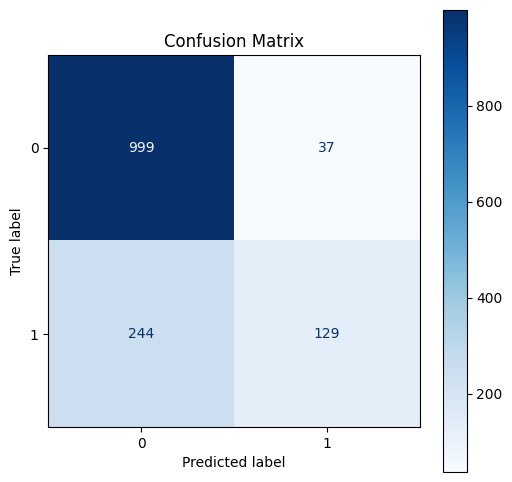

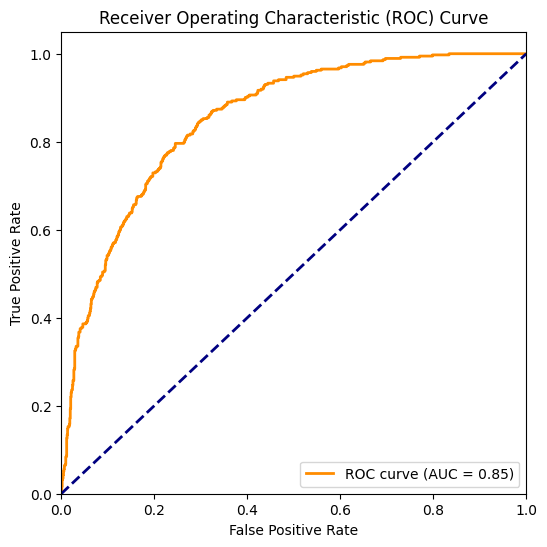

Top features pushing toward churn:
                           Feature  Coefficient
2                     TotalCharges     1.572717
37         Contract_Month-to-month     1.132391
8                      Partner_Yes     0.487563
17     InternetService_Fiber optic     0.475663
28                  TechSupport_No     0.435701
33                 StreamingTV_Yes     0.389089
6                  SeniorCitizen_1     0.384190
36             StreamingMovies_Yes     0.363998
22                 OnlineBackup_No     0.348156
44  PaymentMethod_Electronic check     0.346118

Top features pushing toward non-churn:
                                  Feature  Coefficient
31                         StreamingTV_No     0.000614
7                              Partner_No    -0.032426
30                        TechSupport_Yes    -0.045998
38                      Contract_One year    -0.079816
43  PaymentMethod_Credit card (automatic)    -0.081923
16                    InternetService_DSL    -0.085961
13          

In [10]:

results(0.2, pipeline_minmax)


## Standard

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      1036
           1       0.77      0.35      0.48       373

    accuracy                           0.80      1409
   macro avg       0.79      0.66      0.68      1409
weighted avg       0.80      0.80      0.77      1409



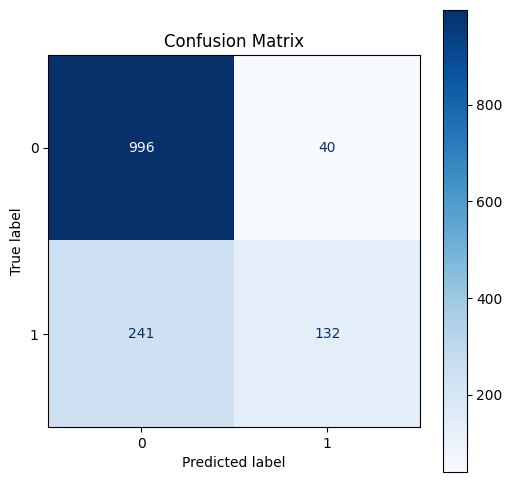

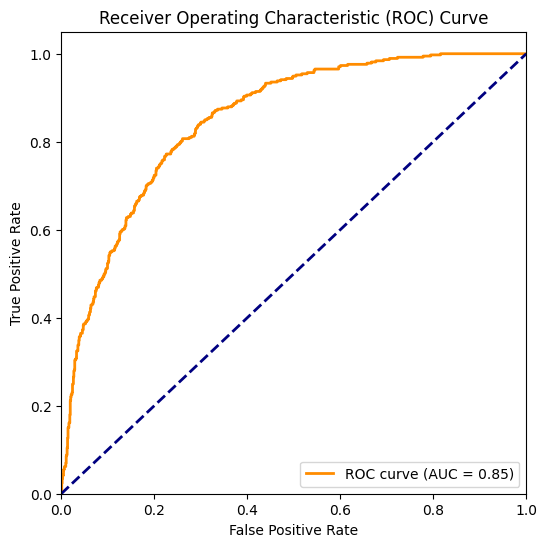

Top features pushing toward churn:
                        Feature  Coefficient
37      Contract_Month-to-month     1.226021
17  InternetService_Fiber optic     0.910409
33              StreamingTV_Yes     0.676449
8                   Partner_Yes     0.671645
36          StreamingMovies_Yes     0.648722
2                  TotalCharges     0.609337
28               TechSupport_No     0.563508
6               SeniorCitizen_1     0.551924
15            MultipleLines_Yes     0.510325
12             PhoneService_Yes     0.485036

Top features pushing toward non-churn:
                                  Feature  Coefficient
20     OnlineSecurity_No internet service     0.050050
18                     InternetService_No     0.050050
32        StreamingTV_No internet service     0.050050
26   DeviceProtection_No internet service     0.050050
43  PaymentMethod_Credit card (automatic)    -0.005130
13                       MultipleLines_No    -0.025288
16                    InternetService_DSL    

In [11]:
results(0.2, pipeline_standard)

# 30% Testing, 70% Training

For a model that uses 30% testing and 70% training, we can see a curve that is more convex and pivoted towards 1. We can see that internet fiberoptic service is a strong indication of customer churn and that the lack of internet service indicates a push towards less customer churn.

## Minmax

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      1539
           1       0.72      0.42      0.53       574

    accuracy                           0.80      2113
   macro avg       0.77      0.68      0.70      2113
weighted avg       0.79      0.80      0.78      2113



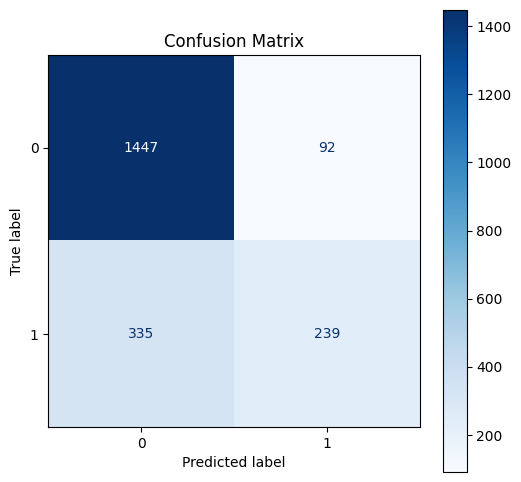

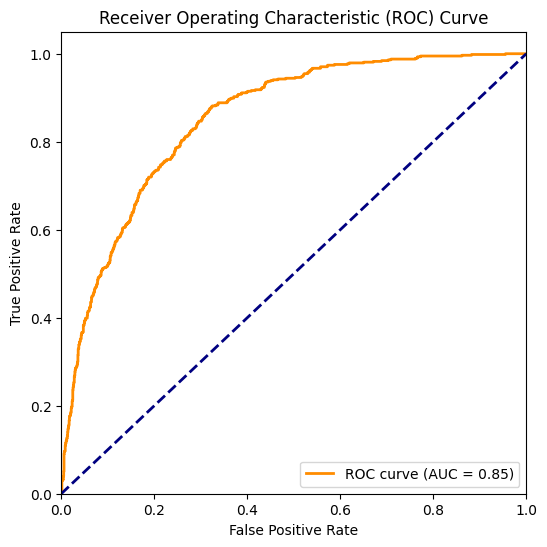

Top features pushing toward churn:
                           Feature  Coefficient
2                     TotalCharges     1.573347
37         Contract_Month-to-month     0.942943
17     InternetService_Fiber optic     0.624190
19               OnlineSecurity_No     0.577145
6                  SeniorCitizen_1     0.432807
8                      Partner_Yes     0.393811
44  PaymentMethod_Electronic check     0.375970
36             StreamingMovies_Yes     0.373606
28                  TechSupport_No     0.373084
22                 OnlineBackup_No     0.372823

Top features pushing toward non-churn:
                                    Feature  Coefficient
23         OnlineBackup_No internet service     0.060797
26     DeviceProtection_No internet service     0.060797
29          TechSupport_No internet service     0.060797
43    PaymentMethod_Credit card (automatic)     0.046101
42  PaymentMethod_Bank transfer (automatic)     0.003199
21                       OnlineSecurity_Yes    -0.12138

In [12]:
results(0.3, pipeline_minmax)

## Standard

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.96      0.86      1539
           1       0.73      0.30      0.43       574

    accuracy                           0.78      2113
   macro avg       0.76      0.63      0.65      2113
weighted avg       0.77      0.78      0.75      2113



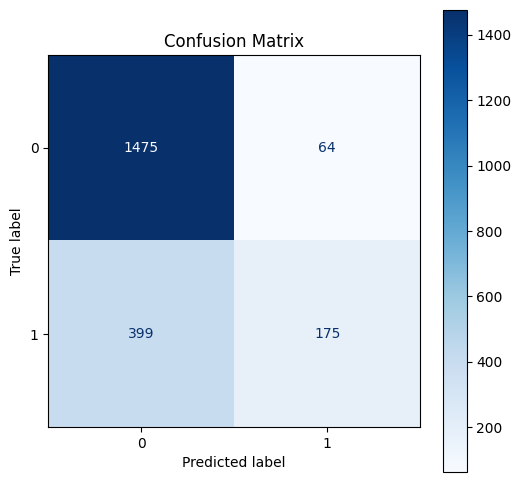

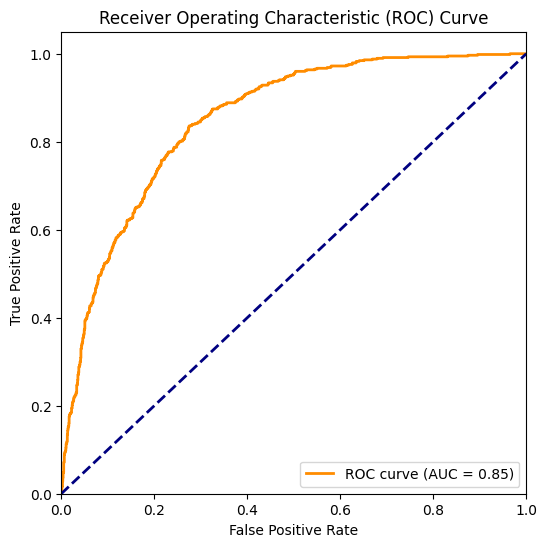

Top features pushing toward churn:
                           Feature  Coefficient
17     InternetService_Fiber optic     1.070096
37         Contract_Month-to-month     0.947772
36             StreamingMovies_Yes     0.775950
33                 StreamingTV_Yes     0.732297
2                     TotalCharges     0.704042
44  PaymentMethod_Electronic check     0.701835
28                  TechSupport_No     0.560869
22                 OnlineBackup_No     0.534228
8                      Partner_Yes     0.524263
6                  SeniorCitizen_1     0.522892

Top features pushing toward non-churn:
                                 Feature  Coefficient
20    OnlineSecurity_No internet service     0.014678
26  DeviceProtection_No internet service     0.014678
23      OnlineBackup_No internet service     0.014678
32       StreamingTV_No internet service     0.014678
45            PaymentMethod_Mailed check     0.000647
34                    StreamingMovies_No    -0.022220
16                 

In [13]:
results(0.3, pipeline_standard)

# 40% Testing, 60% Training


## Minmax

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      2069
           1       0.62      0.61      0.62       749

    accuracy                           0.80      2818
   macro avg       0.74      0.74      0.74      2818
weighted avg       0.80      0.80      0.80      2818



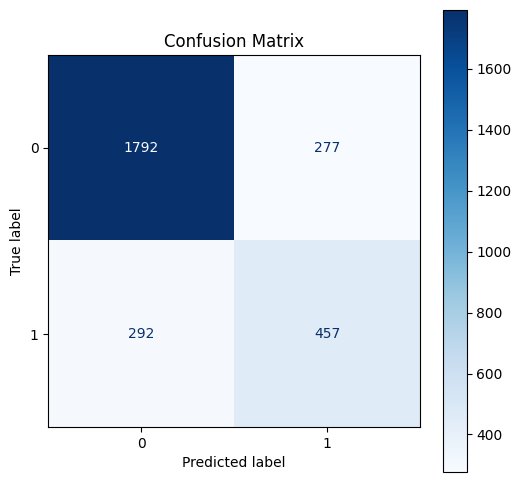

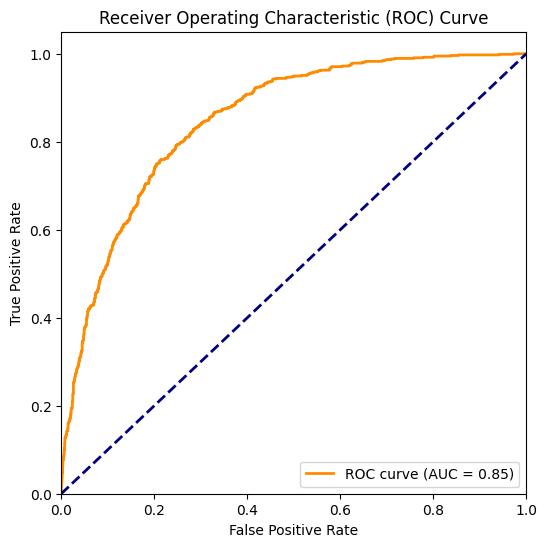

Top features pushing toward churn:
                        Feature  Coefficient
2                  TotalCharges     1.515885
37      Contract_Month-to-month     0.930172
17  InternetService_Fiber optic     0.779870
3                 gender_Female     0.530139
41         PaperlessBilling_Yes     0.483786
9                 Dependents_No     0.481249
36          StreamingMovies_Yes     0.436570
7                    Partner_No     0.390892
19            OnlineSecurity_No     0.383164
28               TechSupport_No     0.358289

Top features pushing toward non-churn:
                       Feature  Coefficient
10              Dependents_Yes     0.076491
40         PaperlessBilling_No     0.073953
34          StreamingMovies_No     0.036894
4                  gender_Male     0.027601
45  PaymentMethod_Mailed check    -0.054932
13            MultipleLines_No    -0.062227
16         InternetService_DSL    -0.306405
1               MonthlyCharges    -0.348066
39           Contract_Two year    

In [14]:
results(0.4, pipeline_minmax)

## Standard

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      2069
           1       0.60      0.71      0.65       749

    accuracy                           0.80      2818
   macro avg       0.75      0.77      0.76      2818
weighted avg       0.81      0.80      0.80      2818



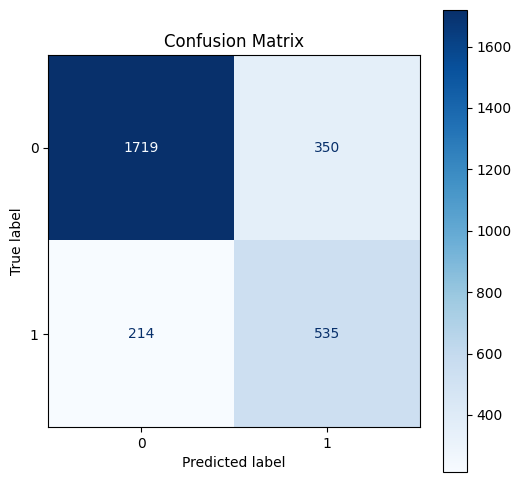

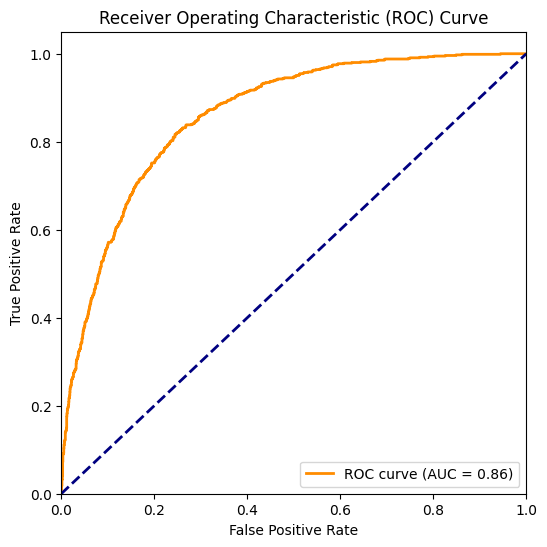

Top features pushing toward churn:
                        Feature  Coefficient
17  InternetService_Fiber optic     1.130742
37      Contract_Month-to-month     0.950600
2                  TotalCharges     0.667058
33              StreamingTV_Yes     0.632540
7                    Partner_No     0.613574
36          StreamingMovies_Yes     0.556566
41         PaperlessBilling_Yes     0.555890
12             PhoneService_Yes     0.539224
27         DeviceProtection_Yes     0.502688
28               TechSupport_No     0.495986

Top features pushing toward non-churn:
                                 Feature  Coefficient
20    OnlineSecurity_No internet service     0.027408
18                    InternetService_No     0.027408
35   StreamingMovies_No internet service     0.027408
32       StreamingTV_No internet service     0.027408
23      OnlineBackup_No internet service     0.027408
26  DeviceProtection_No internet service     0.027408
16                   InternetService_DSL    -0.30448

In [15]:
results(0.4, pipeline_standard)